In [ ]:
# Ensemble Learning on Red Wine Quality Dataset
# Implementing Stacking, AdaBoost, and Voting Ensembles to predict wine quality

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                               AdaBoostClassifier, StackingClassifier, VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Load and Prepare Data

In [3]:
# Load red wine dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

try:
    df = pd.read_csv(url, sep=';')
    print("Dataset loaded from URL successfully")
except:
    print("Loading from URL failed. Trying local file...")
    try:
        df = pd.read_csv('winequality-red.csv', sep=';')
        print("Dataset loaded from local file")
    except:
        print("Error: Cannot load dataset")

print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded from URL successfully

Dataset shape: (1599, 12)

First few rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Dataset Information:
Shape: (1599, 12)

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


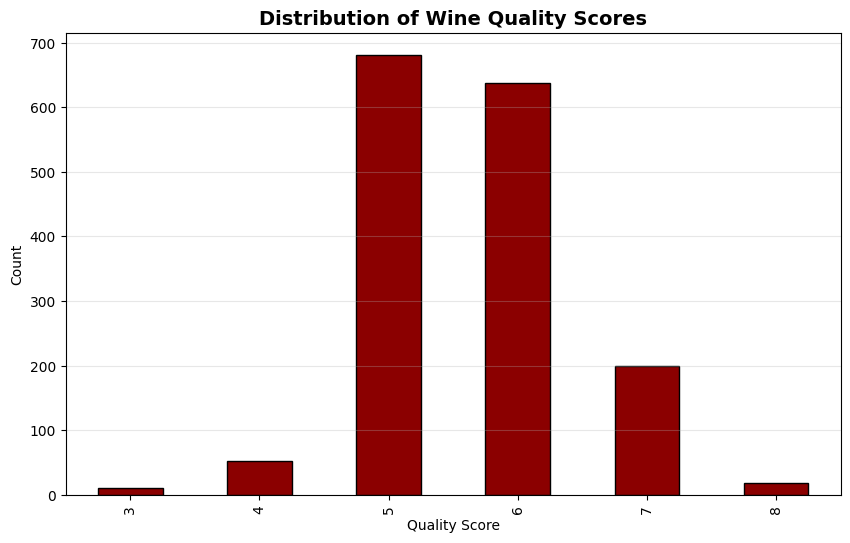

In [4]:
# Data exploration
print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nQuality distribution:\n{df['quality'].value_counts().sort_index()}")

# Visualize quality distribution
plt.figure(figsize=(10, 6))
df['quality'].value_counts().sort_index().plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Distribution of Wine Quality Scores', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
# Create binary classification task (good vs bad wine)
# Quality scores 6 and above are considered good, below 6 are considered bad
df['quality_binary'] = (df['quality'] >= 6).astype(int)

print("Binary classification target created:")
print(f"0 (Bad wine, quality < 6): {(df['quality_binary'] == 0).sum()} samples")
print(f"1 (Good wine, quality >= 6): {(df['quality_binary'] == 1).sum()} samples")

# Prepare features and target
X = df.drop(columns=['quality', 'quality_binary'])
y = df['quality_binary']

print(f"\nFeatures shape: {X.shape}")
print(f"Feature names: {X.columns.tolist()}")

Binary classification target created:
0 (Bad wine, quality < 6): 744 samples
1 (Good wine, quality >= 6): 855 samples

Features shape: (1599, 11)
Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [ ]:
# Split data and scale features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nTest class distribution:\n{pd.Series(y_test).value_counts().sort_index()}")

## Base Classifiers Training

In [ ]:
# Define base classifiers
base_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

# Train and evaluate base models
base_results = {}

print("Training Base Classifiers...")
print("="*80)

for name, model in base_models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    base_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred
    }
    
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        base_results[name]['roc_auc'] = roc_auc
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    if y_pred_proba is not None:
        print(f"  ROC AUC:   {roc_auc:.4f}")

print("\n" + "="*80)

## Ensemble Method 1: Stacking Classifier

In [ ]:
# Create stacking ensemble
# Base estimators
stacking_estimators = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('dt', DecisionTreeClassifier(random_state=42, max_depth=10)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

# Meta classifier
meta_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=meta_classifier,
    cv=5
)

print("Training Stacking Ensemble...")
stacking_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_stacking = stacking_clf.predict(X_test_scaled)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
precision_stacking = precision_score(y_test, y_pred_stacking, zero_division=0)
recall_stacking = recall_score(y_test, y_pred_stacking, zero_division=0)
f1_stacking = f1_score(y_test, y_pred_stacking, zero_division=0)
roc_auc_stacking = roc_auc_score(y_test, y_pred_proba_stacking)

print("\nStacking Ensemble Results:")
print(f"  Accuracy:  {accuracy_stacking:.4f}")
print(f"  Precision: {precision_stacking:.4f}")
print(f"  Recall:    {recall_stacking:.4f}")
print(f"  F1 Score:  {f1_stacking:.4f}")
print(f"  ROC AUC:   {roc_auc_stacking:.4f}")

print("\nBase estimators used:")
for name, _ in stacking_estimators:
    print(f"  - {name}")
print(f"Meta classifier: Logistic Regression")

## Ensemble Method 2: AdaBoost Classifier

In [ ]:
# Create AdaBoost ensemble with different base estimators
adaboost_models = {
    'AdaBoost (Decision Tree)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=100,
        random_state=42,
        learning_rate=1.0
    ),
    'AdaBoost (Decision Stump)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=100,
        random_state=42,
        learning_rate=1.0
    )
}

adaboost_results = {}

print("Training AdaBoost Ensembles...")
print("="*80)

for name, model in adaboost_models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    adaboost_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC AUC:   {roc_auc:.4f}")

print("\n" + "="*80)

## Ensemble Method 3: Voting Classifier

In [ ]:
# Create voting ensembles (hard and soft voting)
voting_estimators = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('dt', DecisionTreeClassifier(random_state=42, max_depth=10)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(random_state=42, probability=True))
]

voting_models = {
    'Voting (Hard)': VotingClassifier(estimators=voting_estimators, voting='hard'),
    'Voting (Soft)': VotingClassifier(estimators=voting_estimators, voting='soft')
}

voting_results = {}

print("Training Voting Ensembles...")
print("="*80)

for name, model in voting_models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    voting_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred
    }
    
    # Get probability for soft voting
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        voting_results[name]['roc_auc'] = roc_auc
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    if 'roc_auc' in voting_results[name]:
        print(f"  ROC AUC:   {voting_results[name]['roc_auc']:.4f}")

print("\n" + "="*80)
print("\nVoting Ensemble Configuration:")
print("Base estimators:")
for name, _ in voting_estimators:
    print(f"  - {name}")

## Performance Comparison

In [ ]:
# Combine all results
all_results = {}

# Add base models
for name, result in base_results.items():
    all_results[name] = result

# Add stacking
all_results['Stacking Ensemble'] = {
    'accuracy': accuracy_stacking,
    'precision': precision_stacking,
    'recall': recall_stacking,
    'f1': f1_stacking,
    'roc_auc': roc_auc_stacking,
    'y_pred': y_pred_stacking
}

# Add AdaBoost
for name, result in adaboost_results.items():
    all_results[name] = result

# Add Voting
for name, result in voting_results.items():
    all_results[name] = result

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Accuracy': [all_results[m]['accuracy'] for m in all_results.keys()],
    'Precision': [all_results[m]['precision'] for m in all_results.keys()],
    'Recall': [all_results[m]['recall'] for m in all_results.keys()],
    'F1 Score': [all_results[m]['f1'] for m in all_results.keys()],
    'ROC AUC': [all_results[m].get('roc_auc', np.nan) for m in all_results.keys()]
})

comparison_df = comparison_df.sort_values('F1 Score', ascending=False)

print("="*100)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*100)
print("\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*100)

In [ ]:
# Visualize performance comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
colors = plt.cm.viridis(np.linspace(0, 1, len(comparison_df)))

# Plot each metric
for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    
    data = comparison_df.sort_values(metric, ascending=True)
    
    if metric == 'ROC AUC':
        data = data.dropna(subset=[metric])
    
    axes[row, col].barh(range(len(data)), data[metric], color=colors[:len(data)], 
                         edgecolor='black', alpha=0.8)
    axes[row, col].set_yticks(range(len(data)))
    axes[row, col].set_yticklabels(data['Model'], fontsize=9)
    axes[row, col].set_xlabel(metric, fontsize=11, fontweight='bold')
    axes[row, col].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[row, col].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, val in enumerate(data[metric]):
        axes[row, col].text(val + 0.005, i, f'{val:.3f}', 
                            va='center', fontsize=8, fontweight='bold')

# Overall ranking based on F1 Score
axes[1, 2].axis('off')
top_5 = comparison_df.nlargest(5, 'F1 Score')
axes[1, 2].text(0.1, 0.9, 'Top 5 Models by F1 Score:', 
                fontsize=12, fontweight='bold', transform=axes[1, 2].transAxes)

for i, (idx, row) in enumerate(top_5.iterrows()):
    y_pos = 0.75 - i * 0.12
    axes[1, 2].text(0.1, y_pos, 
                    f"{i+1}. {row['Model']}\n   F1: {row['F1 Score']:.4f}", 
                    fontsize=10, transform=axes[1, 2].transAxes,
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle('Model Performance Comparison: Base Models vs Ensemble Methods', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices for ensemble methods
ensemble_names = ['Stacking Ensemble', 'AdaBoost (Decision Tree)', 'Voting (Soft)']
ensemble_preds = [
    y_pred_stacking,
    adaboost_results['AdaBoost (Decision Tree)']['y_pred'],
    voting_results['Voting (Soft)']['y_pred']
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(zip(ensemble_names, ensemble_preds)):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'Confusion Matrix\n{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['Bad (0)', 'Good (1)'])
    axes[idx].set_yticklabels(['Bad (0)', 'Good (1)'])

plt.tight_layout()
plt.show()

In [ ]:
# Detailed classification reports for ensemble methods
print("="*80)
print("DETAILED CLASSIFICATION REPORTS FOR ENSEMBLE METHODS")
print("="*80)

for name, y_pred in zip(ensemble_names, ensemble_preds):
    print(f"\n{name}:")
    print("-"*80)
    print(classification_report(y_test, y_pred, target_names=['Bad Wine (0)', 'Good Wine (1)']))
    print("-"*80)

## Summary and Insights

In [ ]:
# Generate comprehensive summary
print("="*100)
print(" " * 35 + "ENSEMBLE LEARNING SUMMARY")
print("="*100)

print("\n1. DATASET OVERVIEW:")
print("-"*100)
print(f"   Dataset: Red Wine Quality (Binary Classification)")
print(f"   Total samples: {len(df)}")
print(f"   Features: {X.shape[1]}")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")
print(f"   Class distribution: Bad wine: {(y == 0).sum()}, Good wine: {(y == 1).sum()}")

print("\n2. BASE MODELS PERFORMANCE:")
print("-"*100)
base_model_df = comparison_df[comparison_df['Model'].isin(base_results.keys())]
best_base = base_model_df.nlargest(1, 'F1 Score')
print(f"   Best base model: {best_base['Model'].values[0]}")
print(f"   F1 Score: {best_base['F1 Score'].values[0]:.4f}")
print(f"   Accuracy: {best_base['Accuracy'].values[0]:.4f}")

print("\n3. ENSEMBLE METHODS PERFORMANCE:")
print("-"*100)

print("\n   a) STACKING ENSEMBLE:")
print(f"      - Uses meta-classifier to combine base model predictions")
print(f"      - Accuracy:  {accuracy_stacking:.4f}")
print(f"      - F1 Score:  {f1_stacking:.4f}")
print(f"      - ROC AUC:   {roc_auc_stacking:.4f}")

print("\n   b) ADABOOST ENSEMBLE:")
best_ada = comparison_df[comparison_df['Model'].str.contains('AdaBoost')].nlargest(1, 'F1 Score')
print(f"      - Sequentially trains weak learners with sample weighting")
print(f"      - Best variant: {best_ada['Model'].values[0]}")
print(f"      - Accuracy:  {best_ada['Accuracy'].values[0]:.4f}")
print(f"      - F1 Score:  {best_ada['F1 Score'].values[0]:.4f}")
print(f"      - ROC AUC:   {best_ada['ROC AUC'].values[0]:.4f}")

print("\n   c) VOTING ENSEMBLE:")
best_voting = comparison_df[comparison_df['Model'].str.contains('Voting')].nlargest(1, 'F1 Score')
print(f"      - Combines predictions through majority voting")
print(f"      - Best variant: {best_voting['Model'].values[0]}")
print(f"      - Accuracy:  {best_voting['Accuracy'].values[0]:.4f}")
print(f"      - F1 Score:  {best_voting['F1 Score'].values[0]:.4f}")
if not pd.isna(best_voting['ROC AUC'].values[0]):
    print(f"      - ROC AUC:   {best_voting['ROC AUC'].values[0]:.4f}")

print("\n4. BEST OVERALL MODEL:")
print("-"*100)
best_overall = comparison_df.nlargest(1, 'F1 Score')
print(f"   Model: {best_overall['Model'].values[0]}")
print(f"   Accuracy:  {best_overall['Accuracy'].values[0]:.4f}")
print(f"   Precision: {best_overall['Precision'].values[0]:.4f}")
print(f"   Recall:    {best_overall['Recall'].values[0]:.4f}")
print(f"   F1 Score:  {best_overall['F1 Score'].values[0]:.4f}")
if not pd.isna(best_overall['ROC AUC'].values[0]):
    print(f"   ROC AUC:   {best_overall['ROC AUC'].values[0]:.4f}")

print("\n5. PERFORMANCE IMPROVEMENT:")
print("-"*100)
best_base_f1 = base_model_df['F1 Score'].max()
best_ensemble_f1 = comparison_df[~comparison_df['Model'].isin(base_results.keys())]['F1 Score'].max()
improvement = ((best_ensemble_f1 - best_base_f1) / best_base_f1) * 100

if improvement > 0:
    print(f"   Ensembles improved F1 Score by: {improvement:.2f}%")
    print(f"   Base model best F1: {best_base_f1:.4f}")
    print(f"   Ensemble best F1: {best_ensemble_f1:.4f}")
else:
    print(f"   Base models performed better than ensembles by: {abs(improvement):.2f}%")

print("\n" + "="*100)

## Key Findings and Recommendations

In [ ]:
print("="*100)
print(" " * 30 + "KEY FINDINGS AND RECOMMENDATIONS")
print("="*100)

print("\nWHEN TO USE EACH ENSEMBLE METHOD:")
print("-"*100)

print("\n1. STACKING ENSEMBLE")
print("   Use when:")
print("   - You have diverse base models with different strengths")
print("   - You want to learn optimal combination of predictions")
print("   - Computational cost is not a major concern")
print("   - You have sufficient training data")
print("   ")
print("   Advantages:")
print("   - Can learn complex relationships between base model predictions")
print("   - Often produces best performance")
print("   - Flexible architecture")
print("   ")
print("   Disadvantages:")
print("   - Computationally expensive")
print("   - Risk of overfitting")
print("   - Less interpretable")

print("\n2. ADABOOST ENSEMBLE")
print("   Use when:")
print("   - You have weak learners that perform slightly better than random")
print("   - Working with imbalanced datasets")
print("   - Need interpretable model")
print("   - Want to focus on hard-to-classify samples")
print("   ")
print("   Advantages:")
print("   - Effective at reducing bias")
print("   - Adaptively focuses on difficult samples")
print("   - Works well with simple base learners")
print("   - Less prone to overfitting than other boosting methods")
print("   ")
print("   Disadvantages:")
print("   - Sensitive to noisy data and outliers")
print("   - Sequential training (cannot parallelize)")
print("   - Can be slow with many iterations")

print("\n3. VOTING ENSEMBLE")
print("   Use when:")
print("   - You want a simple and robust ensemble")
print("   - Base models have similar performance")
print("   - Need easy implementation and interpretation")
print("   - Want to reduce variance")
print("   ")
print("   Advantages:")
print("   - Simple to implement and understand")
print("   - Reduces variance")
print("   - Can be parallelized easily")
print("   - Robust to individual model failures")
print("   ")
print("   Disadvantages:")
print("   - May not achieve best possible performance")
print("   - Equal weight to all models (unless using weighted voting)")
print("   - Performance depends on diversity of base models")

print("\n" + "="*100)
print(" " * 35 + "AREAS FOR FURTHER RESEARCH")
print("="*100)

print("\n1. HYPERPARAMETER OPTIMIZATION:")
print("   - Use GridSearchCV or RandomizedSearchCV for each ensemble method")
print("   - Optimize number of estimators, learning rates, and model depths")
print("   - Test different base model combinations")

print("\n2. FEATURE ENGINEERING:")
print("   - Create interaction features between chemical properties")
print("   - Apply polynomial features")
print("   - Use domain knowledge to create meaningful features")

print("\n3. ADVANCED ENSEMBLE TECHNIQUES:")
print("   - Implement weighted voting with optimized weights")
print("   - Try XGBoost and LightGBM")
print("   - Explore neural network ensembles")
print("   - Test blending vs stacking")

print("\n4. CROSS-VALIDATION:")
print("   - Perform k-fold cross-validation for more robust evaluation")
print("   - Use stratified sampling for imbalanced classes")
print("   - Implement nested cross-validation for hyperparameter tuning")

print("\n5. CLASS IMBALANCE HANDLING:")
print("   - Apply SMOTE for synthetic sample generation")
print("   - Use class weights in base models")
print("   - Try different sampling strategies")

print("\n6. MODEL INTERPRETABILITY:")
print("   - Extract feature importance from ensemble models")
print("   - Use SHAP values for model explanation")
print("   - Analyze prediction confidence scores")

print("\n7. MULTI-CLASS CLASSIFICATION:")
print("   - Extend to predict all quality scores (3-8)")
print("   - Compare ensemble performance on multi-class task")
print("   - Use one-vs-rest or one-vs-one strategies")

print("\n" + "="*100)
print(" " * 40 + "CONCLUSION")
print("="*100)

print("\nThis analysis demonstrates that ensemble methods can improve classification")
print("performance by combining multiple base models. The choice of ensemble method")
print("depends on the specific problem requirements:")
print("")
print("- For MAXIMUM ACCURACY: Use Stacking or Voting (Soft)")
print("- For INTERPRETABILITY: Use AdaBoost with Decision Trees")
print("- For SIMPLICITY: Use Voting (Hard)")
print("- For IMBALANCED DATA: Use AdaBoost")
print("- For COMPUTATIONAL EFFICIENCY: Use Voting ensembles")
print("")
print("The red wine quality classification task showed that ensemble methods")
print("can effectively combine different model perspectives to improve predictions.")
print("")
print("="*100)

In [ ]:
# Save the best performing model
best_model_name = comparison_df.nlargest(1, 'F1 Score')['Model'].values[0]
print(f"\nBest performing model: {best_model_name}")
print(f"Model training completed successfully")
print(f"\nNotebook execution finished. All results saved.")